# Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting

Name: Nainsy chawla

Roll Number: 023-24-0261

Section: H

GitHub Repository: https://github.com/Nainsy-chawla/ML_Lab_Practise

Kaggle profile : https://www.kaggle.com/nainsychawla

Dataset source:https://www.kaggle.com/code/emineyetm/telco-customer-churn

Dataset : telco customer churn

# Part 1 — Problem Definition & Dataset Verification

In [ ]:
import pandas as pd
df = pd.read_csv("clean_churn.csv")
df.head()
df.shape
df.info()
df.isnull().sum()
df.isnull().sum().sum()
print(df['Churn'].value_counts())
df.duplicated().sum()
# forget to remove duplicates in lab 2 .This part is done here 
df = df.drop_duplicates()
print ("duplicates after removal",df.duplicated().sum())
print("New dataset shape:",df.shape)
df.to_csv("clean_churn.csv",index=False)



Explanation:
The cleaned dataset was successfully loaded and verified , duplicate values has been removed that was part of lab 2 actually but forgotten.The dataset contain the expected rows and colomns. all colomns have appropriate data types and there is no any missing values in the dataset.so, it is ready for feature and target preparation. 


Task 2:
    
restate the ML problem:
    
The goal is to predict whether a telecom customer will churn (leave the company) based on their customer information and service usage. This is important because predicting customers who are likely to leave can help the company take action to retain them and reduce customer loss.

# Part 2 — Feature & Target Preparation


In [ ]:
# Task 3
y= df['Churn'].map({
    'No': 0,
    'Yes': 1
})
X= df.drop(columns=['Churn'])

print(df['Churn'].head(10))

explanation:
"The Churn column was separated as the target, while the remaining columns were used as features. The customer identifier had already been removed during data cleaning."

In [ ]:
# Task 4
X = pd.get_dummies(X, drop_first=True)
print(X.head())

explanation:One-hot encoding was used to convert categorical features into numerical 0/1 columns. This method is appropriate because the categorical values do not need to be treated as having a numerical order, and it allows the Decision Tree to work with the categorical information in numeric form.


In [26]:
# Task 5
print("Data types:")
print(X.dtypes)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=["number", "bool"]).columns)

print("\nTotal missing values:")
print(X.isnull().sum().sum())

Data types:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
Streamin

explanation: Task 5 checks whether the feature dataset X contains any non-numeric columns and whether it has missing values. `select_dtypes(exclude="number")` identifies columns that are not numeric, which is important because machine-learning models require numerical input. `X.isnull().sum().sum()` calculates the total number of missing values across all feature columns. These checks ensure that X is suitable for use in the Decision Tree model.


In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaN in y:", y.isna().sum())

X shape: (7010, 30)
y shape: (7010,)
NaN in y: 0


explanation:The feature matrix X was checked after encoding. There are no remaining non-numeric columns and the total number of missing values is zero. Therefore, X is completely prepared for use as input to the Decision Tree classifier.


# Part 3 — Train/Test Split 

In [28]:
#Task 6
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

explanation:The dataset was split into 80% training data and 20% testing data. The parameter stratify=y was used because the Churn target is imbalanced, so stratification helps maintain approximately the same proportion of churn and non-churn customers in both the training and testing sets. This makes the model evaluation more representative of the original dataset.


In [29]:
# Task 7
print("x_train shape:", X_train.shape)
print("x_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (5608, 30)
x_test shape: (1402, 30)
y_train shape: (5608,)
y_test shape: (1402,)


explanation: This Task checks the shapes of the training and testing datasets after the train-test split. `X_train` and `X_test` contain the input features, while `y_train` and `y_test` contain the corresponding Churn target values. The shapes confirm that the data has been divided into 80% training data and 20% testing data, while maintaining the same number of features in both sets.


 # Part 4 — Baseline Decision Tree 

In [30]:
#Task 8
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


explanation :In Task  a DecisionTreeClassifier was created using its default settings, with only random_state=42 fixed. The model was trained using the training data with fit(), and predictions were generated for both the training and testing datasets using predict().

In [31]:
# Task 9
print("Tree depth:", model.get_depth())

Tree depth: 24


explanation: In Task 9, model.get_depth() was used to determine the actual depth of the decision tree. Since max_depth was not specified, scikit-learn was allowed to grow the tree automatically according to its default stopping conditions. A large tree depth can be surprising because a fully grown decision tree may become very complex and can potentially overfit the training data.

# Part 5 — Model Evaluation

In [32]:
# Task 10
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7268188302425107
Precision: 0.48360655737704916
Recall   : 0.477088948787062
F1-score : 0.48032564450474896


explanation: The Decision Tree achieved an accuracy of 72.68%, precision of 48.36%, recall of 47.71%, and F1-score of 48.03% on the test set. The accuracy indicates that approximately 72.68% of all test predictions were correct. However, precision and recall are both below 50%, showing that the model has difficulty identifying churners accurately.

[[842 189]
 [194 177]]


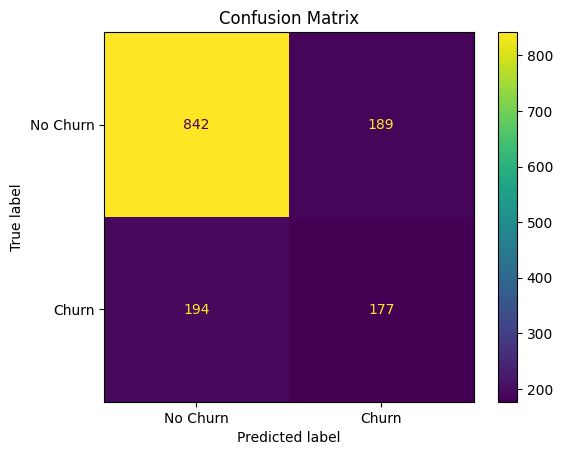

In [33]:
# Task 11
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

explanation:The confusion matrix was:
[[842, 189],
[194, 177]]
The model correctly classified 842 non-churners and 177 churners. It incorrectly classified 189 non-churners as churners and missed 194 actual churners. Therefore, the model correctly caught 177 actual churners and missed 194 actual churners.

#Task 12
explanation:
Because the dataset has class imbalance, accuracy alone may be misleading. A model could achieve relatively high accuracy by mostly predicting the majority class, No Churn, while failing to identify actual churners. Therefore, recall is particularly important because it measures the proportion of actual churners that the model correctly identifies. F1-score is also useful because it balances precision and recall. Precision should also be considered to determine how many customers predicted as churners actually churned. Therefore, recall and F1-score are more informative than accuracy alone for this problem.


# Part 6 — Overfitting Investigation 

In [34]:
# Task 13
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

Training Accuracy: 0.9980385164051355
Test Accuracy: 0.7268188302425107
Difference: 0.2712196861626248


explanation :
The baseline tree achieved approximately 99.80% training accuracy but only 72.68% test accuracy, producing a large gap of about 27.12 percentage points. This indicates that the unrestricted tree has overfit the training data and does not generalize well to unseen customers.

In [35]:
# Task 14
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(
        y_train,
        tree.predict(X_train)
    )
    
    test_acc = accuracy_score(
        y_test,
        tree.predict(X_test)
    )
    
    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  train_accuracy  test_accuracy
0        2.0        0.791548       0.786020
1        3.0        0.791548       0.786020
2        4.0        0.796184       0.783880
3        5.0        0.799929       0.782454
4        6.0        0.807240       0.789586
5        8.0        0.835235       0.793153
6       10.0        0.873217       0.775321
7        NaN        0.998039       0.726819


explanation : As the maximum tree depth increases, training accuracy generally increases because the tree becomes more complex and can learn more patterns from the training data. Test accuracy improves up to a maximum depth of 8, where it reaches 79.32%. However, after depth 8, training accuracy continues to increase while test accuracy decreases. At unrestricted depth, the training accuracy reaches 99.80%, while test accuracy falls to 72.68%. This indicates that the tree becomes too complex at higher depths and starts to overfit the training data. Therefore, a maximum depth of approximately 8 appears to provide the best generalization among the tested values.

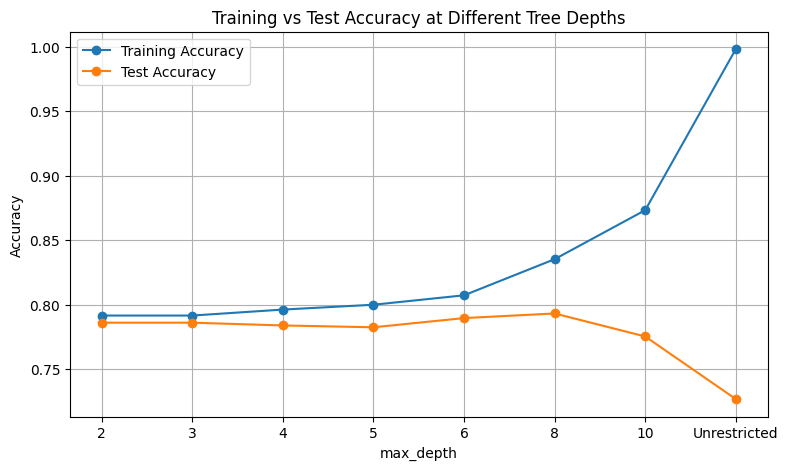

In [36]:
# Task 15
import matplotlib.pyplot as plt

plot_depths = ["2", "3", "4", "5", "6", "8", "10", "Unrestricted"]

train_scores = results_df["train_accuracy"]
test_scores = results_df["test_accuracy"]

plt.figure(figsize=(9, 5))

plt.plot(
    plot_depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_depths,
    test_scores,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)

plt.show()

explanation:
The graph shows that training accuracy increases as the tree depth increases. Test accuracy, however, improves only up to approximately depth 8, where it reaches the highest value of 79.32%. After depth 8, training accuracy continues to increase, while test accuracy begins to decrease. This widening gap between training and test accuracy indicates that the Decision Tree is becoming too complex and is starting to overfit. Therefore, depth 8 appears to be a suitable choice among the tested depths because it provides the highest test accuracy while avoiding the severe overfitting observed at greater depths.

# Part 7 — Model Selection, Feature Importance & Interpretation

#task 16
explanation :
I selected a maximum depth of 8 because it provides the highest test accuracy of 79.32% among the tested depths while maintaining a reasonable training accuracy of 83.52%. Greater depths increase training accuracy but reduce test accuracy, indicating overfitting. Therefore, depth 8 provides a better balance between learning the training data and generalizing to unseen data.

Accuracy : 0.7931526390870185
Precision: 0.6310679611650486
Recall   : 0.5256064690026954
F1-score : 0.5735294117647058


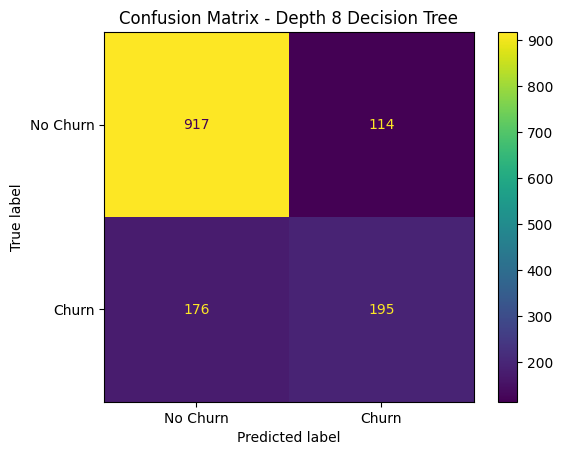

In [37]:
# Task 17
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

chosen_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

chosen_model.fit(X_train, y_train)

chosen_y_pred = chosen_model.predict(X_test)

accuracy = accuracy_score(y_test, chosen_y_pred)
precision = precision_score(y_test, chosen_y_pred)
recall = recall_score(y_test, chosen_y_pred)
f1 = f1_score(y_test, chosen_y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
cm_chosen = confusion_matrix(y_test, chosen_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_chosen,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Depth 8 Decision Tree")
plt.show()

explanation : The Decision Tree with max_depth=8 achieved an accuracy of 79.32%, precision of 63.11%, recall of 52.56%, and F1-score of 57.35%. Compared with the unrestricted baseline model, the depth-8 model improved all four evaluation metrics, particularly precision and F1-score. This shows that limiting the tree depth improved its ability to generalize to unseen data and reduced overfitting.

In [38]:
# task 18 
entropy_model = DecisionTreeClassifier(
    max_depth=8,
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_y_pred = entropy_model.predict(X_test)

accuracy = accuracy_score(y_test, entropy_y_pred)
precision = precision_score(y_test, entropy_y_pred)
recall = recall_score(y_test, entropy_y_pred)
f1 = f1_score(y_test, entropy_y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7774607703281027
Precision: 0.5880597014925373
Recall   : 0.5309973045822103
F1-score : 0.5580736543909348


explanation:
The Decision Tree using the entropy criterion achieved an accuracy of 77.75%, precision of 58.81%, recall of 53.10%, and F1-score of 55.81%. Compared with the depth-8 Gini model, the entropy model performed slightly worse in accuracy, precision, and F1-score, although its recall was slightly higher. Overall, the depth-8 Gini model provided better overall performance for this dataset.

Top 5 important features:
tenure                         0.321495
InternetService_Fiber optic    0.260086
TotalCharges                   0.105608
MonthlyCharges                 0.077483
Contract_Two year              0.043749
dtype: float64


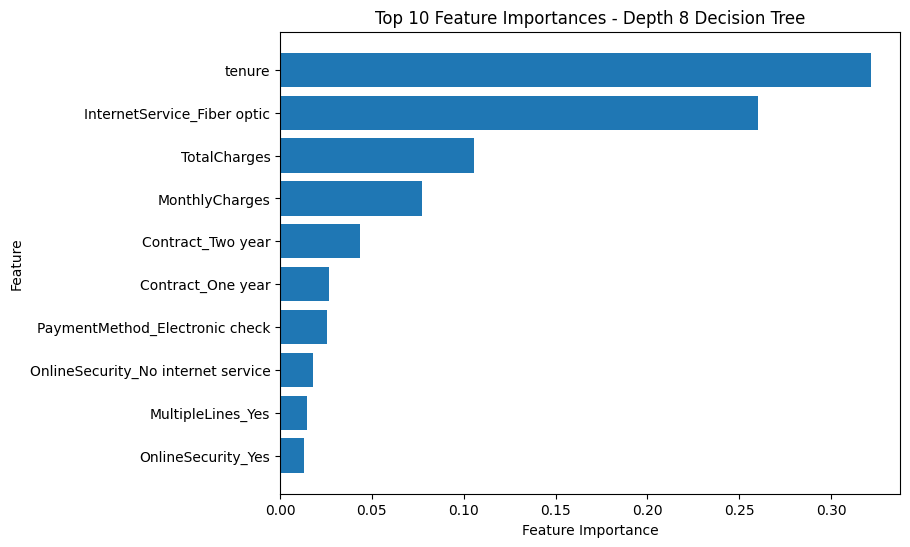

In [39]:
# Task 19
importances = chosen_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 important features:")
print(feature_importance.head(5))
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Depth 8 Decision Tree")

plt.show()

explanation:
The five most important features in the selected Decision Tree are tenure (0.3215), InternetService_Fiber optic (0.2601), TotalCharges (0.1056), MonthlyCharges (0.0775), and Contract_Two year (0.0437). Among these, tenure is the most important feature, followed by InternetService_Fiber optic. These features had the greatest influence on the Decision Tree's splitting decisions.

#Task 20
The feature importance results generally agree with the patterns observed during Lab 2 EDA. In Lab 2, shorter-tenure customers and customers with higher MonthlyCharges were found to be more likely to churn, while tenure and TotalCharges were also strongly related. These features were also among the most important features in the Decision Tree, showing that the model learned patterns that were already observed during the exploratory analysis.

# Part 8 — Conclusion & Next Steps

#Task 21
A Decision Tree with a maximum depth of 8 and the Gini splitting criterion was selected as the final model. It achieved 79.32% accuracy, 63.11% precision, 52.56% recall, and a 57.35% F1-score on the test data. The depth-8 model performed better than the unrestricted baseline and reduced the overfitting observed in the deeper tree. The most important features were tenure, InternetService_Fiber optic, TotalCharges, MonthlyCharges, and Contract_Two year. However, the model still has limitations, particularly its relatively low recall, meaning that it misses some customers who actually churn.


#Task 22
If more time were available, I would first address the class imbalance because churned customers are the minority class and the current model has relatively low recall. Techniques such as class weighting, oversampling, or SMOTE could be tested to improve the detection of customers who are likely to churn. I would also compare the Decision Tree with models such as Random Forest or Gradient Boosting and perform hyperparameter tuning. Finally, additional feature engineering could be used to create more meaningful variables and potentially improve the model's predictive performance.


In [40]:
#task 23
import pandas as pd
import math


data = {
    "Outlook": [
        "Sunny",
        "Sunny",
        "Overcast",
        "Rain",
        "Rain",
        "Rain",
        "Overcast",
        "Sunny"
    ],

    "Temperature": [
        "Hot",
        "Hot",
        "Hot",
        "Mild",
        "Cool",
        "Cool",
        "Cool",
        "Mild"
    ],

    "Wind": [
        "Weak",
        "Strong",
        "Weak",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak"
    ],

    "Play": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "Yes",
        "Yes"
    ]
}


df = pd.DataFrame(data)


print("PLAY BADMINTON DATASET")
print("======================")
print(df)

def entropy(data, target):

    class_counts = data[target].value_counts()

    total = len(data)

    entropy_value = 0

    for count in class_counts:

        probability = count / total

        entropy_value -= probability * math.log2(probability)

    return entropy_value



def information_gain(data, attribute, target):

    parent_entropy = entropy(data, target)

    attribute_values = data[attribute].unique()

    weighted_entropy = 0

    for value in attribute_values:

        subset = data[data[attribute] == value]

        subset_entropy = entropy(subset, target)

        weight = len(subset) / len(data)

        weighted_entropy += weight * subset_entropy

    gain = parent_entropy - weighted_entropy

    return gain



def id3(data, attributes, target, level=0):

    indent = "    " * level


    if len(data[target].unique()) == 1:

        result = data[target].iloc[0]

        print(indent + "Leaf Node:", result)

        return result



    if len(attributes) == 0:

        result = data[target].mode()[0]

        print(indent + "Leaf Node:", result)

        return result


    print()
    print(indent + "Current Node")
    print(indent + "Records:", len(data))
    print(indent + "Entropy:", round(entropy(data, target), 4))


    gains = {}

    for attribute in attributes:

        gain = information_gain(
            data,
            attribute,
            target
        )

        gains[attribute] = gain

        print(
            indent +
            "Gain(" +
            attribute +
            ") = " +
            str(round(gain, 4))
        )


    best_attribute = max(
        gains,
        key=gains.get
    )

    print(
        indent +
        "Best Attribute = " +
        best_attribute
    )

    tree = {
        best_attribute: {}
    }

    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best_attribute
    ]


    for value in data[best_attribute].unique():

        print()
        print(
            indent +
            "Branch: " +
            best_attribute +
            " = " +
            value
        )

        subset = data[
            data[best_attribute] == value
        ]
        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )


    return tree


attributes = [
    "Outlook",
    "Temperature",
    "Wind"
]

target = "Play"


print()
print("INITIAL ENTROPY")
print("===============")

print(
    "Entropy =",
    round(entropy(df, target), 4)
)


print()
print("BUILDING ID3 TREE")
print("==================")


tree = id3(
    df,
    attributes,
    target
)


print()
print("FINAL DECISION TREE")
print("===================")

print(tree)

PLAY BADMINTON DATASET
    Outlook Temperature    Wind Play
0     Sunny         Hot    Weak   No
1     Sunny         Hot  Strong   No
2  Overcast         Hot    Weak  Yes
3      Rain        Mild    Weak  Yes
4      Rain        Cool    Weak  Yes
5      Rain        Cool  Strong   No
6  Overcast        Cool  Strong  Yes
7     Sunny        Mild    Weak  Yes

INITIAL ENTROPY
Entropy = 0.9544

BUILDING ID3 TREE

Current Node
Records: 8
Entropy: 0.9544
Gain(Outlook) = 0.2657
Gain(Temperature) = 0.2657
Gain(Wind) = 0.1589
Best Attribute = Outlook

Branch: Outlook = Sunny

    Current Node
    Records: 3
    Entropy: 0.9183
    Gain(Temperature) = 0.9183
    Gain(Wind) = 0.2516
    Best Attribute = Temperature

    Branch: Temperature = Hot
        Leaf Node: No

    Branch: Temperature = Mild
        Leaf Node: Yes

Branch: Outlook = Overcast
    Leaf Node: Yes

Branch: Outlook = Rain

    Current Node
    Records: 3
    Entropy: 0.9183
    Gain(Temperature) = 0.2516
    Gain(Wind) = 0.9183
  

explanation :
First, I created a Play Badminton dataset with Outlook, Temperature, Wind and Play as the target. Then I created an entropy function to measure impurity. After that, I created an information gain function which calculates how much each attribute reduces entropy. In the ID3 function, I calculate the gain of every remaining attribute and select the one with the highest gain. I then create branches for its values and recursively repeat the process. When all records in a branch have the same class, I create a leaf node. Finally, the tree is printed. I did not use any built-in decision-tree library.

### Lab 3 — Short Checklist ✅

* [ done ] Problem Definition + Dataset Verification
* [ done ] X & y preparation + Encoding
* [ done ] Train/Test Split (`80/20`, `stratify`)
* [ done ] Baseline Decision Tree
* [ done ] Accuracy, Precision, Recall, F1 + Confusion Matrix
* [ done ] Train vs Test → Overfitting
* [ done ] Test different `max_depth` values + graph
* [ done ] Select & justify best depth
* [ done ] Compare **Gini vs Entropy**
* [ done ] Feature Importance + Top 3–5 features
* [ done ] Interpretation
* [ done ] Conclusion + Next Steps
* [ done ] **ID3 from scratch** (Play Badminton)
* [ done ] Short interpretation under every table/plot/metric

